# ART Defenses

This notebook reuses the canonical data, model, and attack patterns from the attacks notebook to showcase deckard's ART defense support.

The focus here is on defense *types* and *composition rules*, not on claiming that every defense improves every metric on these tiny synthetic examples.

The runnable defense categories in this repo are:

- `preprocessor`
- `postprocessor`
- `trainer`
- `detector`
- `transformer`

`regularizer` is catalogued in the model layer but is not yet implemented, so it is documented below rather than executed.

### Scope and Guardrails

This notebook focuses on defense composition semantics rather than leaderboards.

- The examples prioritize API clarity and reproducible wiring over maximizing any single metric.
- Not all defenses are expected to improve all attack scenarios.
- `regularizer` remains documented but non-runnable until implementation lands.

Use this notebook with {doc}`/notebooks/art_attacks` to compare attack-only and defended pipelines under the same runtime contracts.

In [1]:
from __future__ import annotations

import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn

from deckard.frameworks.pytorch.attack import PytorchAttackConfig
from deckard.attack import AttackConfig
from deckard.data import DataConfig
from deckard.data import PytorchDataConfig
from deckard.data.sample import SplitSampler
from deckard.model import ModelConfig
from deckard.frameworks.pytorch.model import PytorchModelConfig
from deckard.model.defense.base import DefenseConfig

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

sns.set_theme(style="whitegrid", palette="colorblind")

ARTIFACT_DIR = Path("build/art_defenses")
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)

torch_model_file = ARTIFACT_DIR / "torch_model.pkl"

/Users/c.meyers/.pyenv/versions/3.10.20/envs/deckard/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def as_numeric(value):
    if isinstance(value, (int, float, np.integer, np.floating)):
        return float(value)
    return value


def wrapper_defense_names(wrapper, attr_name):
    defenses = getattr(wrapper, attr_name, None) or []
    return [type(defense).__name__ for defense in defenses]


def summarize_wrapper(wrapper):
    return {
        "art_wrapper_class": type(wrapper).__name__,
        "preprocessors": ", ".join(
            wrapper_defense_names(wrapper, "preprocessing_defences")
        )
        or "none",
        "postprocessors": ", ".join(
            wrapper_defense_names(wrapper, "postprocessing_defences")
        )
        or "none",
        "detector_attached": hasattr(wrapper, "_deckard_evasion_detector"),
    }


def plot_defense_accuracy(df, title):
    plot_df = df.melt(
        id_vars=["label", "defense_type"],
        value_vars=["clean_accuracy", "attack_accuracy"],
        var_name="metric_label",
        value_name="metric_value",
    )
    plt.figure(figsize=(10, 4.5))
    sns.barplot(data=plot_df, x="label", y="metric_value", hue="metric_label")
    plt.ylim(0, 1)
    plt.title(title)
    plt.xlabel("Configuration")
    plt.ylabel("Accuracy")
    plt.xticks(rotation=15)
    plt.tight_layout()
    plt.show()


def make_sklearn_evasion_data(seed=SEED, class_sep=1.4):
    data = DataConfig(
        name="make_classification",
        data_params={
            "n_samples": 220,
            "n_features": 10,
            "n_informative": 6,
            "n_redundant": 0,
            "n_clusters_per_class": 1,
            "n_classes": 2,
            "class_sep": class_sep,
            "random_state": seed,
        },
        classifier=True,
        sampler=SplitSampler(
            train_size=160,
            test_size=60,
            random_state=seed,
            stratify=True,
        ),
    )
    data()
    return data


def make_sklearn_fgm_attack(eps=0.15, eps_step=0.05, attack_size=24):
    return AttackConfig(
        name="art.attacks.evasion.FastGradientMethod",
        attack_params={
            "eps": eps,
            "eps_step": eps_step,
            "norm": "inf",
            "targeted": False,
            "minimal": False,
        },
        attack_size=attack_size,
    )


class TinyNet(nn.Module):
    def __init__(self, in_features=8, hidden_features=16, out_features=2):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(in_features, hidden_features),
            nn.ReLU(),
            nn.Linear(hidden_features, out_features),
        )

    def forward(self, x):
        return self.layers(x)


def build_torch_tensor_data(seed=SEED):
    torch.manual_seed(seed)
    X = torch.rand(72, 8)
    weights = torch.tensor(
        [0.8, -0.4, 0.6, 0.2, -0.3, 0.5, -0.1, 0.4], dtype=torch.float32
    )
    logits = X @ weights
    y = (logits > logits.median()).long()
    data = PytorchDataConfig(
        name="torch.utils.data.TensorDataset",
        classifier=True,
        sampler=SplitSampler(
            train_size=48,
            test_size=24,
            random_state=seed,
            stratify=False,
        ),
        data_params={"_args_": [X, y]},
    )
    data()
    return data


def make_torch_fgm_attack(eps=0.12, eps_step=0.04, attack_size=12):
    return PytorchAttackConfig(
        name="art.attacks.evasion.FastGradientMethod",
        attack_params={
            "eps": eps,
            "eps_step": eps_step,
            "norm": "inf",
            "targeted": False,
            "minimal": False,
        },
        attack_size=attack_size,
    )


def evaluate_config(label, defense_type, name, data, model, attack):
    model(data)
    scores = attack(data=data, model=model)
    art_wrapper = model.get_art_model(data)
    return {
        "label": label,
        "defense_type": defense_type,
        "name": name,
        "clean_accuracy": float(scores["benign_accuracy"]),
        "attack_accuracy": float(scores["evasion_accuracy"]),
        "attack_generation_time": as_numeric(scores.get("attack_generation_time")),
        "defense_application_time": as_numeric(
            getattr(model, "defense_application_time", None)
        ),
        **summarize_wrapper(art_wrapper),
    }


def defense_label(defense_obj):
    token = None
    if isinstance(defense_obj, dict):
        token = defense_obj.get("name")
    else:
        token = getattr(defense_obj, "name", None)
    return str(token or type(defense_obj).__name__)


def explain_defense_chain(pipeline):
    requested = pipeline.normalize_defenses(pipeline.defenses)
    executed = list(requested)
    retraining = [d for d in executed if pipeline._is_retraining_defense(d)]
    if retraining:
        non_retraining = [
            d for d in executed if not pipeline._is_retraining_defense(d)
        ]
        first_retraining_idx = next(
            i for i, d in enumerate(executed) if pipeline._is_retraining_defense(d)
        )
        last_non_retraining_idx = max(
            (
                i
                for i, d in enumerate(executed)
                if not pipeline._is_retraining_defense(d)
            ),
            default=-1,
        )
        if first_retraining_idx < last_non_retraining_idx:
            executed = non_retraining + retraining
    return pd.DataFrame(
        [
            {
                "requested_order": " -> ".join(defense_label(d) for d in requested),
                "executed_order": " -> ".join(defense_label(d) for d in executed),
                "trainer_runs_last": any(
                    pipeline._is_retraining_defense(d) for d in requested
                ),
            }
        ]
    )

## Defense Catalog

The examples below reuse the same canonical patterns as the attacks notebook:

- sklearn `LogisticRegression` on `make_classification` with `FastGradientMethod`
- torch `TinyNet` on `TensorDataset` with `FastGradientMethod`

That keeps the notebook focused on defense behavior rather than changing the victim task at the same time.

In [3]:
defense_catalog = pd.DataFrame(
    [
        {
            "defense_type": "preprocessor",
            "example_defense": "FeatureSqueezing",
            "canonical_victim": "sklearn LogisticRegression",
            "paired_attack": "FastGradientMethod",
            "status": "implemented",
        },
        {
            "defense_type": "postprocessor",
            "example_defense": "ClassLabels",
            "canonical_victim": "sklearn LogisticRegression",
            "paired_attack": "FastGradientMethod",
            "status": "implemented",
        },
        {
            "defense_type": "trainer",
            "example_defense": "AdversarialTrainerMadryPGD",
            "canonical_victim": "torch TinyNet",
            "paired_attack": "FastGradientMethod",
            "status": "implemented",
        },
        {
            "defense_type": "detector",
            "example_defense": "BinaryInputDetector",
            "canonical_victim": "torch TinyNet",
            "paired_attack": "FastGradientMethod",
            "status": "implemented",
        },
        {
            "defense_type": "transformer",
            "example_defense": "DefensiveDistillation",
            "canonical_victim": "torch TinyNet",
            "paired_attack": "FastGradientMethod",
            "status": "implemented",
        },
        {
            "defense_type": "regularizer",
            "example_defense": "catalogued only",
            "canonical_victim": "n/a",
            "paired_attack": "n/a",
            "status": "not implemented in deckard.model.defense.base",
        },
    ]
)

display(defense_catalog)

,defense_type,example_defense,canonical_victim,paired_attack,status
0,preprocessor,FeatureSqueezing,sklearn LogisticRegression,FastGradientMethod,implemented
1,postprocessor,ClassLabels,sklearn LogisticRegression,FastGradientMethod,implemented
2,trainer,AdversarialTrainerMadryPGD,torch TinyNet,FastGradientMethod,implemented
3,detector,BinaryInputDetector,torch TinyNet,FastGradientMethod,implemented
4,transformer,DefensiveDistillation,torch TinyNet,FastGradientMethod,implemented
5,regularizer,catalogued only,n/a,n/a,not implemented in deckard.model.defense.base


## Preprocessor and Postprocessor Defenses

This section stays closest to the sklearn evasion example from the attacks notebook. The victim is the same logistic-regression classifier on `make_classification`, and the paired attack is the same `FastGradientMethod`.

The defense chain example combines a preprocessor with a postprocessor on the same victim model.

,label,defense_type,name,clean_accuracy,attack_accuracy,attack_generation_time,defense_application_time,art_wrapper_class,preprocessors,postprocessors,detector_attached
0,baseline,baseline,none,1.0,0.62,0.000400,NaN,ScikitlearnLogisticRegression,none,none,False
1,feature_squeezing,preprocessor,art.defences.preprocessor.FeatureSqueezing,1.0,0.62,0.000247,1.332955e-06,ScikitlearnLogisticRegression,none,none,False
2,class_labels,postprocessor,art.defences.postprocessor.ClassLabels,1.0,0.62,0.000255,9.159558e-07,ScikitlearnLogisticRegression,none,none,False
3,feature_squeezing_then_class_labels,chain,FeatureSqueezing -> ClassLabels,1.0,0.62,0.000247,1.667009e-06,ScikitlearnLogisticRegression,none,none,False


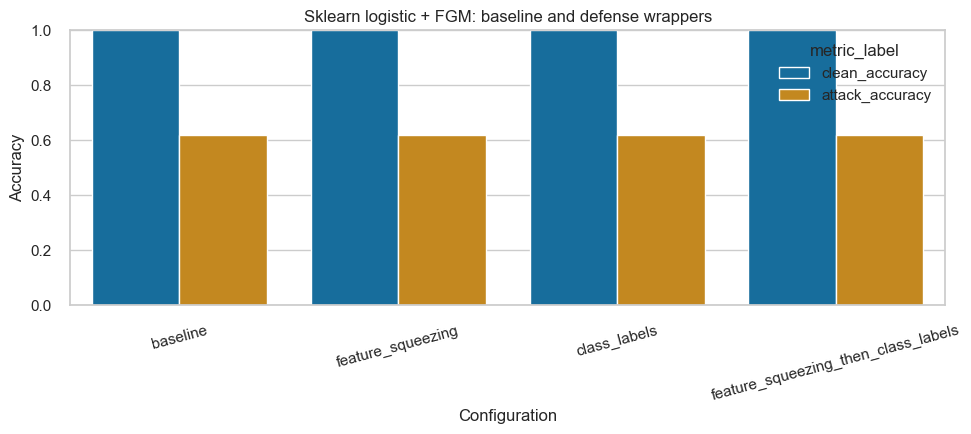

In [4]:
sklearn_defense_data = make_sklearn_evasion_data(class_sep=1.0)
sklearn_defense_attack = make_sklearn_fgm_attack(eps=0.3, eps_step=0.1)

sklearn_defense_runs = [
    (
        "baseline",
        "baseline",
        "none",
        ModelConfig(
            name="sklearn.linear_model.LogisticRegression",
            classifier=True,
            model_params={"max_iter": 300},
        ),
    ),
    (
        "feature_squeezing",
        "preprocessor",
        "art.defences.preprocessor.FeatureSqueezing",
        ModelConfig(
            name="sklearn.linear_model.LogisticRegression",
            classifier=True,
            model_params={"max_iter": 300},
            defense=DefenseConfig(
                defenses=[
                    {
                        "_target_": "deckard.model.defense.base.DefenseConfig",
                        "name": "art.defences.preprocessor.FeatureSqueezing",
                        "defense_params": {
                            "apply_fit": False,
                            "apply_predict": True,
                            "bit_depth": 8,
                            "clip_values": [0, 255],
                        },
                    }
                ]
            ),
        ),
    ),
    (
        "class_labels",
        "postprocessor",
        "art.defences.postprocessor.ClassLabels",
        ModelConfig(
            name="sklearn.linear_model.LogisticRegression",
            classifier=True,
            model_params={"max_iter": 300},
            defense=DefenseConfig(
                defenses=[
                    {
                        "_target_": "deckard.model.defense.base.DefenseConfig",
                        "name": "art.defences.postprocessor.ClassLabels",
                        "defense_params": {"apply_fit": False, "apply_predict": True},
                    }
                ]
            ),
        ),
    ),
    (
        "feature_squeezing_then_class_labels",
        "chain",
        "FeatureSqueezing -> ClassLabels",
        ModelConfig(
            name="sklearn.linear_model.LogisticRegression",
            classifier=True,
            model_params={"max_iter": 300},
            defense=DefenseConfig(
                defenses=[
                    {
                        "_target_": "deckard.model.defense.base.DefenseConfig",
                        "name": "art.defences.preprocessor.FeatureSqueezing",
                        "defense_params": {
                            "apply_fit": False,
                            "apply_predict": True,
                            "bit_depth": 8,
                            "clip_values": [0, 255],
                        },
                    },
                    {
                        "_target_": "deckard.model.defense.base.DefenseConfig",
                        "name": "art.defences.postprocessor.ClassLabels",
                        "defense_params": {"apply_fit": False, "apply_predict": True},
                    },
                ]
            ),
        ),
    ),
]

sklearn_defense_results = pd.DataFrame(
    [
        evaluate_config(
            label,
            defense_type,
            name,
            sklearn_defense_data,
            model,
            sklearn_defense_attack,
        )
        for label, defense_type, name, model in sklearn_defense_runs
    ]
)

display(sklearn_defense_results)
plot_defense_accuracy(
    sklearn_defense_results[
        ["label", "defense_type", "clean_accuracy", "attack_accuracy"]
    ],
    "Sklearn logistic + FGM: baseline and defense wrappers",
)

sklearn_defense_results.to_csv(
    ARTIFACT_DIR / "sklearn_defense_results.csv", index=False
)

## Trainer, Detector, and Transformer Defenses

These examples reuse the same torch `TinyNet` plus `FastGradientMethod` setup from the attacks notebook. The goal is to show the supported ART defense *types* on the same neural victim path.

`BinaryInputDetector` is included here as a detector-type example. deckard preserves the normal classifier interface and attaches the detector object to the ART wrapper.

,label,defense_type,name,clean_accuracy,attack_accuracy,attack_generation_time,defense_application_time,art_wrapper_class,preprocessors,postprocessors,detector_attached
0,baseline,baseline,none,0.42,0.5,0.001029,NaN,PyTorchClassifier,none,none,False
1,adversarial_trainer,trainer,art.defences.trainer.AdversarialTrainerMadryPGD,0.42,0.5,0.000828,0.000001,PyTorchClassifier,none,none,False
2,binary_input_detector,detector,art.defences.detector.evasion.BinaryInputDetector,0.42,0.5,0.000681,0.000001,PyTorchClassifier,none,none,False
3,defensive_distillation,transformer,art.defences.transformer.evasion.DefensiveDist...,0.42,0.5,0.000606,0.000002,PyTorchClassifier,none,none,False


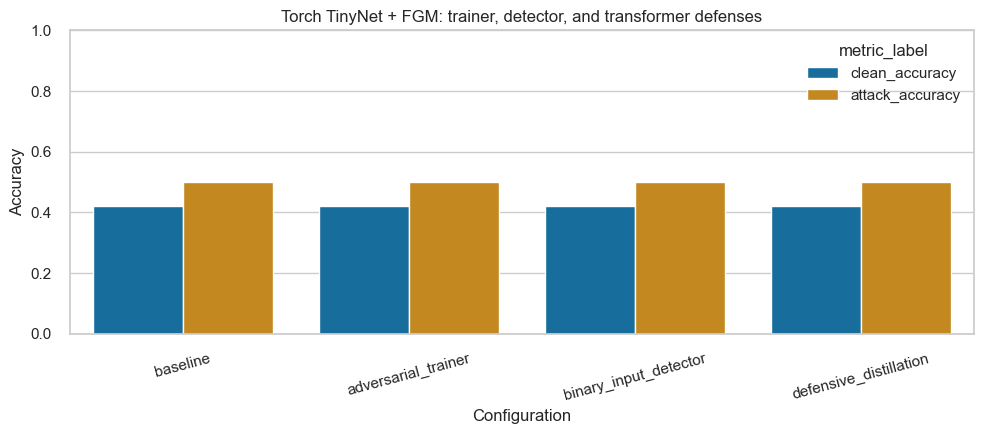

In [5]:
torch_defense_data = build_torch_tensor_data()
torch_defense_attack = make_torch_fgm_attack()

torch_defense_runs = [
    (
        "baseline",
        "baseline",
        "none",
        PytorchModelConfig(
            name=TinyNet,
            model_params={"in_features": 8, "hidden_features": 16, "out_features": 2},
            classifier=True,
            fit_params={"nb_epochs": 3, "batch_size": 16},
            criterion="CrossEntropyLoss",
            optimizer={"name": "SGD", "lr": 0.05},
        ),
    ),
    (
        "adversarial_trainer",
        "trainer",
        "art.defences.trainer.AdversarialTrainerMadryPGD",
        PytorchModelConfig(
            name=TinyNet,
            model_params={"in_features": 8, "hidden_features": 16, "out_features": 2},
            classifier=True,
            fit_params={"nb_epochs": 3, "batch_size": 16},
            criterion="CrossEntropyLoss",
            optimizer={"name": "SGD", "lr": 0.05},
            defense=DefenseConfig(
                defenses=[
                    {
                        "_target_": "deckard.model.defense.base.DefenseConfig",
                        "name": "art.defences.trainer.AdversarialTrainerMadryPGD",
                        "defense_params": {
                            "nb_epochs": 1,
                            "batch_size": 8,
                            "eps": 0.2,
                            "eps_step": 0.1,
                            "max_iter": 1,
                            "num_random_init": 1,
                        },
                    }
                ]
            ),
        ),
    ),
    (
        "binary_input_detector",
        "detector",
        "art.defences.detector.evasion.BinaryInputDetector",
        PytorchModelConfig(
            name=TinyNet,
            model_params={"in_features": 8, "hidden_features": 16, "out_features": 2},
            classifier=True,
            fit_params={"nb_epochs": 3, "batch_size": 16},
            criterion="CrossEntropyLoss",
            optimizer={"name": "SGD", "lr": 0.05},
            defense=DefenseConfig(
                defenses=[
                    {
                        "_target_": "deckard.model.defense.base.DefenseConfig",
                        "name": "art.defences.detector.evasion.BinaryInputDetector",
                        "defense_params": {},
                    }
                ]
            ),
        ),
    ),
    (
        "defensive_distillation",
        "transformer",
        "art.defences.transformer.evasion.DefensiveDistillation",
        PytorchModelConfig(
            name=TinyNet,
            model_params={"in_features": 8, "hidden_features": 16, "out_features": 2},
            classifier=True,
            fit_params={"nb_epochs": 3, "batch_size": 16},
            criterion="CrossEntropyLoss",
            optimizer={"name": "SGD", "lr": 0.05},
            defense=DefenseConfig(
                defenses=[
                    {
                        "_target_": "deckard.model.defense.base.DefenseConfig",
                        "name": "art.defences.transformer.evasion.DefensiveDistillation",
                        "defense_params": {"batch_size": 8, "nb_epochs": 1},
                    }
                ]
            ),
        ),
    ),
]

torch_defense_results = pd.DataFrame(
    [
        evaluate_config(
            label,
            defense_type,
            name,
            torch_defense_data,
            model,
            torch_defense_attack,
        )
        for label, defense_type, name, model in torch_defense_runs
    ]
)

display(torch_defense_results)
plot_defense_accuracy(
    torch_defense_results[
        ["label", "defense_type", "clean_accuracy", "attack_accuracy"]
    ],
    "Torch TinyNet + FGM: trainer, detector, and transformer defenses",
)

torch_defense_results.to_csv(ARTIFACT_DIR / "torch_defense_results.csv", index=False)

## Defense Chains

A defense chain is just a [DefensePipelineConfig](../api/modules) containing several defense specs. Two practical rules matter here:

- The chain preserves user order for ordinary defenses.
- Adversarial retraining defenses are forced to run last, even if they are requested earlier in the chain.

The example below intentionally requests the trainer first so the normalized execution order is visible.

,requested_order,executed_order,trainer_runs_last
0,art.defences.trainer.AdversarialTrainerMadryPG...,art.defences.trainer.AdversarialTrainerMadryPG...,False


,label,defense_type,name,clean_accuracy,attack_accuracy,attack_generation_time,defense_application_time,art_wrapper_class,preprocessors,postprocessors,detector_attached
0,trainer_first_requested_chain,chain,AdversarialTrainerMadryPGD -> FeatureSqueezing...,0.67,0.67,0.000677,0.000003,PyTorchClassifier,none,none,False


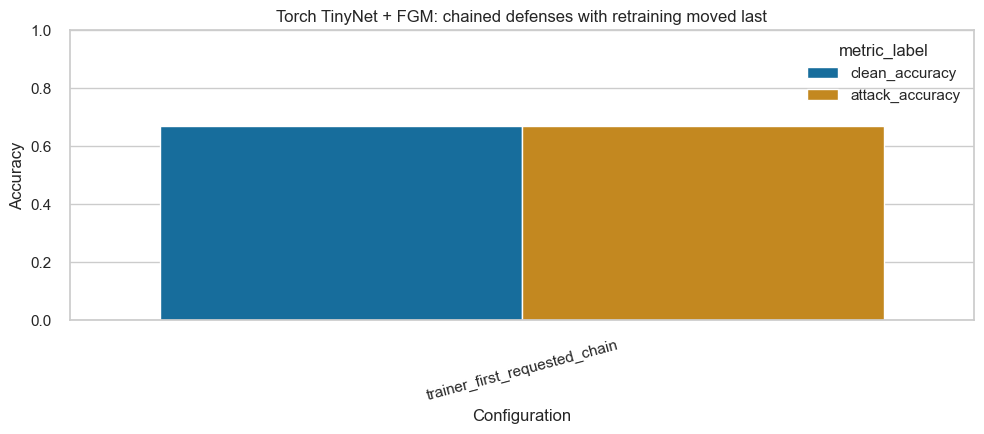

In [6]:
chain_pipeline = DefenseConfig(
    defenses=[
        {
            "_target_": "deckard.model.defense.base.DefenseConfig",
            "name": "art.defences.trainer.AdversarialTrainerMadryPGD",
            "defense_params": {
                "nb_epochs": 1,
                "batch_size": 8,
                "eps": 0.2,
                "eps_step": 0.1,
                "max_iter": 1,
                "num_random_init": 1,
            },
        },
        {
            "_target_": "deckard.model.defense.base.DefenseConfig",
            "name": "art.defences.preprocessor.FeatureSqueezing",
            "defense_params": {
                "apply_fit": False,
                "apply_predict": True,
                "bit_depth": 4,
                "clip_values": [0.0, 1.0],
            },
        },
        {
            "_target_": "deckard.model.defense.base.DefenseConfig",
            "name": "art.defences.postprocessor.ClassLabels",
            "defense_params": {"apply_fit": False, "apply_predict": True},
        },
    ]
)

chain_order_df = explain_defense_chain(chain_pipeline)
display(chain_order_df)

chain_model = PytorchModelConfig(
    name=TinyNet,
    model_params={"in_features": 8, "hidden_features": 16, "out_features": 2},
    classifier=True,
    fit_params={"nb_epochs": 3, "batch_size": 16},
    criterion="CrossEntropyLoss",
    optimizer={"name": "SGD", "lr": 0.05},
    defense=chain_pipeline,
)

chain_result_df = pd.DataFrame(
    [
        evaluate_config(
            label="trainer_first_requested_chain",
            defense_type="chain",
            name="AdversarialTrainerMadryPGD -> FeatureSqueezing -> ClassLabels",
            data=build_torch_tensor_data(seed=SEED + 3),
            model=chain_model,
            attack=make_torch_fgm_attack(eps=0.25, eps_step=0.08),
        )
    ]
)

display(chain_result_df)
plot_defense_accuracy(
    chain_result_df[["label", "defense_type", "clean_accuracy", "attack_accuracy"]],
    "Torch TinyNet + FGM: chained defenses with retraining moved last",
)

chain_order_df.to_csv(ARTIFACT_DIR / "defense_chain_order.csv", index=False)
chain_result_df.to_csv(ARTIFACT_DIR / "defense_chain_result.csv", index=False)

## Optional Dependencies

This notebook runs ART defense workflows, including torch-backed examples.

Recommended extras:

- `docs`
- `torch`

Install from repository root:

```bash
pip install -e '.[docs,torch]'
```

In [7]:
# Optional dependency installation (run only if your environment is missing packages)
# !pip install -e '../../.[docs,torch]'